# Decision Tree Classification

This notebook investigates the use of Decision Tree classification for predicting machine failures using the predictive maintenance dataset.

The experiments focus on:
- classifier performance
- model generalisation
- overfitting and underfitting
- parameter tuning
- evaluation using multiple classification metrics

## Imports 

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Machine Learning Imports

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Dataset

In [21]:
df = pd.read_csv('../data/predictive_maintenance.csv')

# Dataset Preprocessing

The dataset was preprocessed before model training.

The following preprocessing steps were applied:
- removal of identifiers
- removal of leakage features
- one-hot encoding of categorical variables

In [4]:
df_clean = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

df_clean = pd.get_dummies(df_clean, columns=['Type'])

df_clean = df_clean.astype(int, errors='ignore')

df_clean.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_H,Type_L,Type_M
0,298,308,1551,42,0,0,0,0,1
1,298,308,1408,46,3,0,0,1,0
2,298,308,1498,49,5,0,0,1,0
3,298,308,1433,39,7,0,0,1,0
4,298,308,1408,40,9,0,0,1,0


## Feature and Target Selection

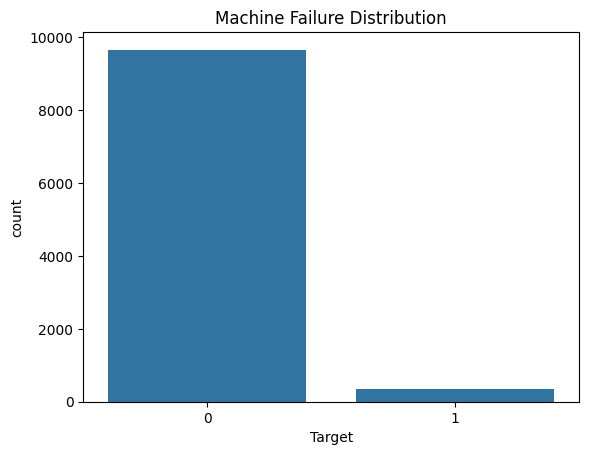

In [5]:
sns.countplot(x='Target', data=df)

plt.title('Machine Failure Distribution')

plt.show()

In [6]:
X = df_clean.drop('Target', axis=1)

y = df_clean['Target']

## Train-Test Split

The dataset was split into training and testing subsets using an 80/20 ratio.

Stratified sampling was used to preserve the class imbalance distribution across both subsets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Baseline Decision Tree Model

An initial Decision Tree classifier was trained using default parameters to establish baseline performance.

In [8]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## Make Predictions

In [9]:
y_pred = dt_model.predict(X_test)

## Evaluate 

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.976

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.65      0.63      0.64        68

    accuracy                           0.98      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.98      0.98      0.98      2000



## Confusion Matrix

The confusion matrix provides insight into:
- true positives
- false positives
- false negatives
- true negatives

This is particularly important for imbalanced datasets where accuracy alone may be misleading.

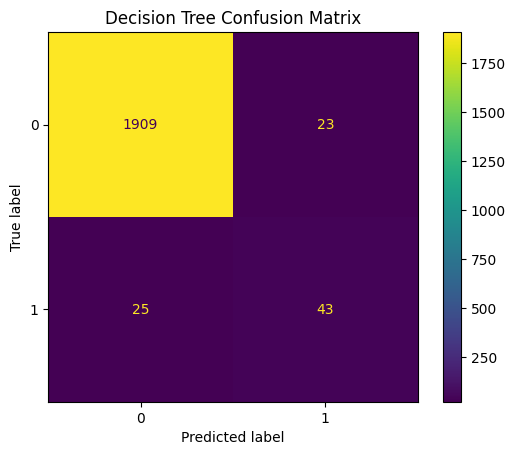

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()

## Initial Model Evaluation

The baseline Decision Tree classifier achieved an overall accuracy of 97.6%. However, due to the significant class imbalance within the dataset, accuracy alone is not a sufficient performance measure.

The classifier achieved a recall score of 0.63 for the failure class, meaning approximately 63% of machine failures were correctly identified. However, approximately 37% of actual failures were missed.

In an industrial predictive maintenance context, false negatives are particularly important because undetected failures may result in equipment damage, production downtime, or safety risks.

The confusion matrix also showed a relatively low number of false positives, suggesting the model did not excessively predict failures unnecessarily.

# Decision Tree Depth Experiments

Additional experiments were performed to investigate the effect of tree depth on classifier performance and model generalisation.

Reducing tree depth may reduce overfitting but can also lead to underfitting if the model becomes too simple.

In [12]:
depths = [3, 5, 10, None]

results = []

for depth in depths:
    
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        'max_depth': depth,
        'accuracy': accuracy
    })

results_df = pd.DataFrame(results)

results_df

,max_depth,accuracy
0,3.0,0.9710
1,5.0,0.9765
2,10.0,0.9820
3,NaN,0.9760


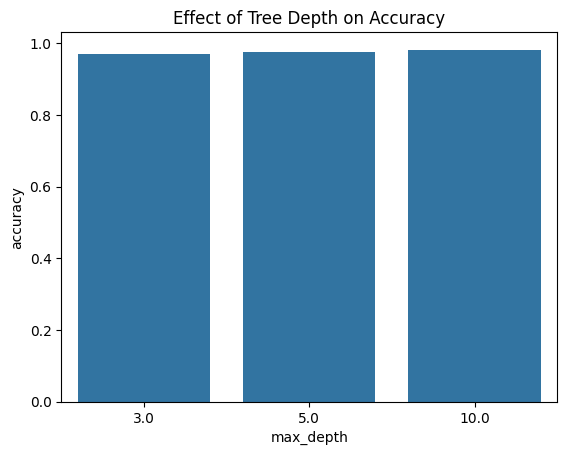

In [13]:
sns.barplot(
    x='max_depth',
    y='accuracy',
    data=results_df
)

plt.title('Effect of Tree Depth on Accuracy')

plt.show()

## Tree Depth Analysis

The effect of tree depth on classifier performance was investigated using several maximum depth values.

The results showed that increasing tree depth initially improved classifier accuracy, with the best performance achieved using a maximum depth of 10.

However, the unrestricted Decision Tree performed slightly worse than the depth-limited model. This suggests that the unrestricted classifier may have overfitted the training data by learning noise and highly specific patterns that did not generalise effectively to unseen test data.

These results demonstrate the importance of controlling model complexity in Decision Tree classifiers to balance learning capability and generalisation performance.

In [14]:
depths = [3, 5, 10, None]

results = []

for depth in depths:
    
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    results.append({
        'max_depth': depth,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy
    })

results_df = pd.DataFrame(results)

results_df

,max_depth,train_accuracy,test_accuracy
0,3.0,0.973250,0.9710
1,5.0,0.979625,0.9765
2,10.0,0.993125,0.9820
3,NaN,1.000000,0.9760


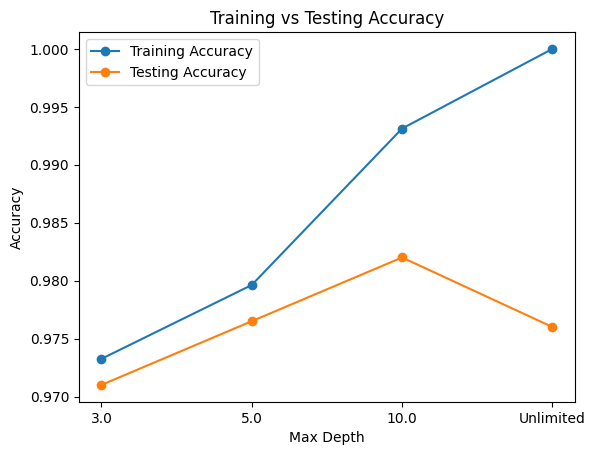

In [15]:
results_df['max_depth'] = results_df['max_depth'].fillna('Unlimited')

plt.plot(
    results_df['max_depth'].astype(str),
    results_df['train_accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    results_df['max_depth'].astype(str),
    results_df['test_accuracy'],
    marker='o',
    label='Testing Accuracy'
)

plt.title('Training vs Testing Accuracy')

plt.xlabel('Max Depth')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

## Overfitting Analysis

The relationship between training and testing accuracy provides strong evidence of overfitting as tree depth increases.

The unrestricted Decision Tree achieved 100% training accuracy, indicating that the model perfectly memorised the training dataset. However, testing accuracy decreased compared to the depth-limited model.

This suggests that the unrestricted classifier learned highly specific patterns and noise within the training data that did not generalise effectively to unseen observations.

The model with a maximum depth of 10 achieved the best balance between learning capability and generalisation performance.

These results demonstrate the importance of controlling Decision Tree complexity to avoid overfitting in predictive maintenance classification tasks.

# Visualise The Tree

In [16]:
from sklearn.tree import plot_tree

In [17]:
small_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

small_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

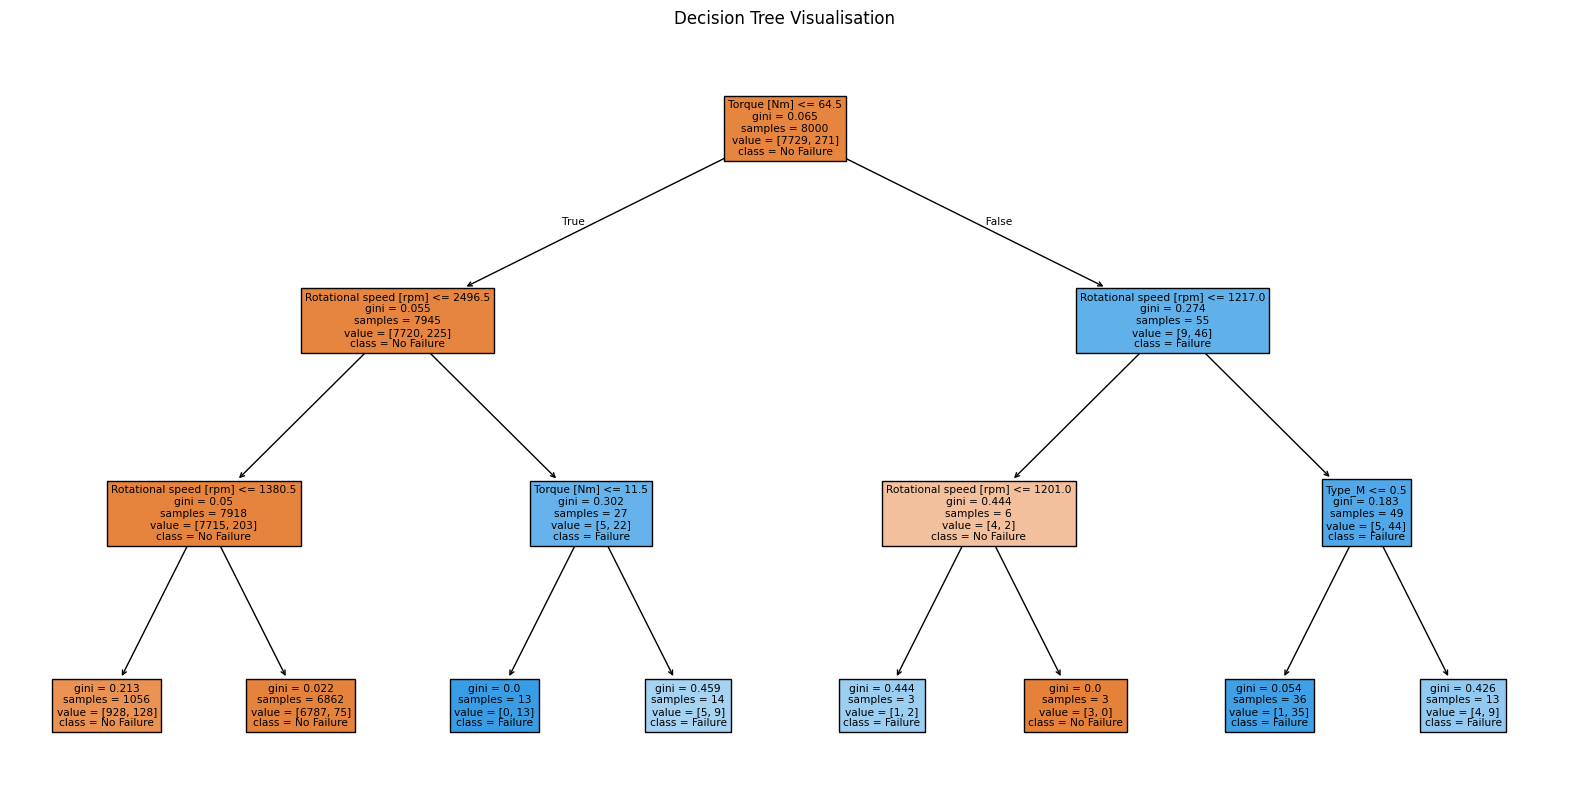

In [18]:
plt.figure(figsize=(20,10))

plot_tree(
    small_tree,
    feature_names=X.columns,
    class_names=['No Failure', 'Failure'],
    filled=True
)

plt.title('Decision Tree Visualisation')

plt.show()